In [63]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit

from nuop_utils import (
    ParallelGateReplacementPass,
    cnot_gate,
    fsim_gate,
    cphase_gate,
    xy_gate,
    get_gate_unitary_qiskit,
)

from qiskit.quantum_info import random_unitary
from tqdm import tqdm
from qiskit.quantum_info import Operator, average_gate_fidelity

In [64]:
# SYC
nuop_decomposer = ParallelGateReplacementPass(
    gate_defs=[fsim_gate],
    gate_params=[[np.pi / 2, np.pi / 6]],
    gate_labels=["SYC"],
    fidelity_dict_2q_gate={(0, 1): [1.0]},
    fidelity_list_1q_gate=[1.0 for _ in range(54)],
    tol=0.0,
)

nuop1_decomposer = ParallelGateReplacementPass(
    gate_defs=[fsim_gate],
    gate_params=[[np.pi / 4, np.pi / 12]],
    gate_labels=["sqrtSYC"],
    fidelity_dict_2q_gate={(0, 1): [1.0]},
    fidelity_list_1q_gate=[1.0 for _ in range(54)],
    tol=0.0,
)

nuop2_decomposer = ParallelGateReplacementPass(
    gate_defs=[fsim_gate, fsim_gate],
    gate_params=[[np.pi / 2, np.pi / 6], [np.pi / 4, np.pi / 12]],
    gate_labels=["SYC", "sqrtSYC"],
    fidelity_dict_2q_gate={(0, 1): [1.0, 1.0]},
    fidelity_list_1q_gate=[1.0 for _ in range(54)],
    tol=0.0,
)

nuop3_decomposer = ParallelGateReplacementPass(
    gate_defs=[cphase_gate, xy_gate],
    gate_params=[[np.pi], [np.pi]],
    gate_labels=["CZ", "XY"],
    fidelity_dict_2q_gate={(0, 1): [1.0, 1.0]},
    fidelity_list_1q_gate=[1.0 for _ in range(54)],
    tol=0.0,
)

nuop4_decomposer = ParallelGateReplacementPass(
    gate_defs=[xy_gate],
    gate_params=[[np.pi / 4]],
    gate_labels=["sq4iswap"],
    fidelity_dict_2q_gate={(0, 1): [1.0]},
    fidelity_list_1q_gate=[1.0 for _ in range(54)],
    tol=0.0,
)

In [ ]:
cost_dict = {
    "SYC": 1.0,
    "sqrtSYC": 0.5,
    "sq4iswap": 0.25,
}


def nuop_to_cost(output_qc):
    cost = 0
    for i in output_qc:
        cost += cost_dict.get(i.operation.label, 0)
        # if i.operation.name == "u3":
        #     continue
        # if not i.operation.label:
        #     continue
        # # use operation.label for cost
        # if i.operation.label in cost_dict:
        #     cost += cost_dict[i.operation.label]
        # else:
        #     print(f"Unknown gate label: {i.operation.label}")
    return cost

In [77]:
N = 100
fidelities = []
costs = []

for idx in tqdm(range(N)):
    input_qc = QuantumCircuit(2)
    input_qc.append(random_unitary(4, seed=idx), [0, 1])
    # input_qc.swap(0, 1)
    output_qc = nuop4_decomposer.run(input_qc, exact_decom=True)

    u = Operator(input_qc)
    v = Operator(output_qc)
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)
    costs.append(nuop_to_cost(output_qc))

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")
print(f"Expected cost: {np.mean(costs)}")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [03:26<00:00,  2.06s/it]


Summary across 100 samples:
  Median fidelity: 0.9999999994688357
  Mean fidelity:   0.9999999794812343
  Minimum fidelity:0.999998408666879
Expected cost: 1.0975


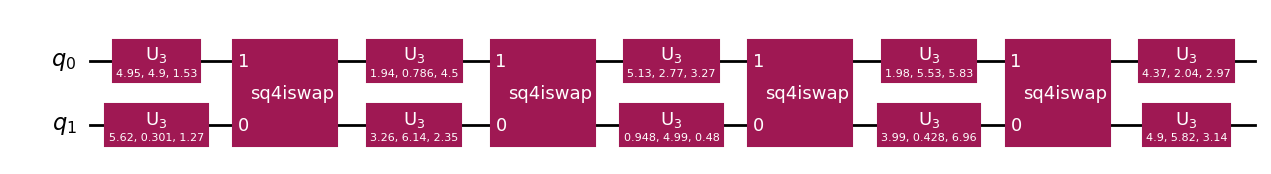

In [67]:
output_qc.draw("mpl")

In [68]:
# 0.9999999999969282, 0.9999999994745845
# what is relative improvement in interms of infidelity?
a = 1 - 0.9999999999971709
b = 1 - 0.9999999994161235
infidelity_factor = b / a
infidelity_factor

206.38458519739424